# Data Project Nelly Harsch

# Dataset Description

To apply the methods covered in the *Python for Data Analysis* course, we will use a dataset provided by the *EC-funded CAVIAR Project* (IST 2001 37540).

In 2003 and 2004, as part of the CAVIAR project, a number of video clips were recorded depicting different scenarios of interest. These include, among others, people walking alone, meeting with others, window shopping, and entering or exiting shops in a public place.

More information about the project can be be found at:  
http://homepages.inf.ed.ac.uk/rbf/CAVIAR/

For this data analysis project, only the front-view recordings from the second dataset, *Clips from Shopping Center in Portugal*, will be used. This subset contains 26 video sequences, each consisting of approximately 1,500 frames, all recorded from the same camera angle.

# Data Loading

In [1]:
import os
import xml.dom.minidom
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

Matplotlib is building the font cache; this may take a moment.


Two sample frames of the dataset can be seen here:

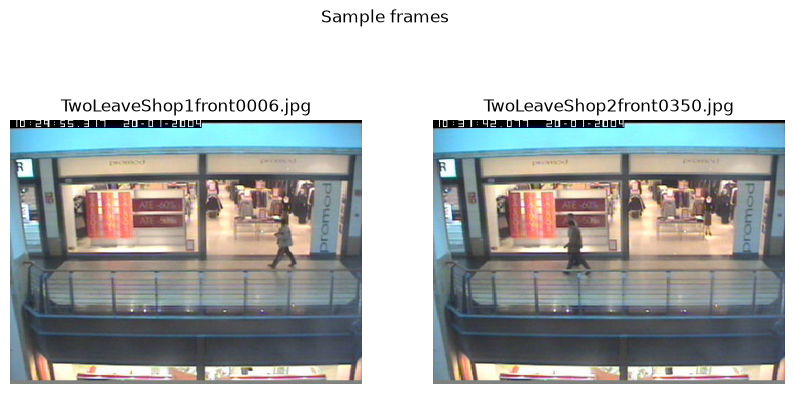

In [2]:
frame_dir = 'sample_frames/'
frame_files = os.listdir(frame_dir)

fig, axes = plt.subplots(1, len(frame_files), figsize = (5*len(frame_files),5))

for ax, frame_name in zip(axes, frame_files):
    frame_path = os.path.join(frame_dir, frame_name)
    img = Image.open(frame_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(frame_path))
    ax.axis("off")
plt.suptitle("Sample frames")
plt.tight_layout
plt.show()

A great advantage of this datset is that CAVIAR also provides the hand-labeled ground truth of all frames. In XML files we can find information  on all people present in a frame. Among other data we get the precise bounding box coordinates and acticity labels for every visible person in every frame.

For the first example frame from above the ground truth looks like this:

In [3]:
xml_path = "sample.xml"
with open(xml_path, "r") as f:
    raw_xml = f.read()

dom = xml.dom.minidom.parseString(raw_xml)
pretty_xml = dom.toprettyxml(indent=" ")
lines = pretty_xml.splitlines()
non_empty_lines = [line for line in lines if line.strip()]

print("\n".join(non_empty_lines[:60]))

<?xml version="1.0" ?>
<dataset name="TwoLeaveShop1front">
 <frame number="6">
  <objectlist>
   <object id="0">
    <orientation>90</orientation>
    <box xc="296" yc="134" w="32" h="55"/>
    <appearance>visible</appearance>
    <hypothesislist>
     <hypothesis id="1" prev="1.0" evaluation="1.0">
      <movement evaluation="1.0">walking</movement>
      <role evaluation="1.0">walker</role>
      <context evaluation="1.0">walking</context>
      <situation evaluation="1.0">moving</situation>
     </hypothesis>
    </hypothesislist>
   </object>
  </objectlist>
  <grouplist/>
 </frame>
</dataset>


As a result, we base our analysis entirely on the provided ground truth XML files. All information needed for our calculations can be directly obtaind form the XML files. To work with the ground truth we parse the XML files and generate a DataFrame where each row represents one person in one frame. This way, we also get rid of all the information on frames where no person is present. 

In [4]:
def parse_xml(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    rows = []
    for frame in root.findall('frame'):
        frame_number = int(frame.get('number'))
        objects = frame.findall('.objectlist/object')

        if len(objects) == 0:
            rows.append({
                'sequence': os.path.basename(filepath).replace('.xml', ''),
                'frame': frame_number,
                'obj_id': None,
                'xc': None, 
                'yc': None, 
                'w': None, 
                'h': None,
                'appearance': None,
                'orientation': None,
                'movement': None,
                'role': None,
                'context': None,
                'situation': None
            })
        else:
            for obj in objects:
                obj_id = int(obj.get('id'))
                box = obj.find('box')
                xc = int(box.get('xc'))
                yc = int(box.get('yc'))
                w = int(box.get('w'))
                h = int(box.get('h'))
                appearance = obj.findtext('appearance')
                orientation = obj.findtext('orientation')

                hyp = obj.find('./hypothesislist/hypothesis')
                if hyp is not None:
                    movement = hyp.findtext('movement')
                    role = hyp.findtext('role')
                    context = hyp.findtext('context')
                    situation = hyp.findtext('situation')
                else:
                    movement = role = context = situation = None
                
                rows.append({
                    'sequence': os.path.basename(filepath).replace('.xml', ''),
                    'frame': frame_number,
                    'obj_id': obj_id,
                    'xc': xc,
                    'yc': yc,
                    'h': h,
                    'w': w,
                    'appearance': appearance,
                    'orientation': orientation,
                    'movement': movement,
                    'role': role,
                    'context': context,
                    'situation': situation
                })
    return rows

In [5]:
data_dir = 'data/'
all_rows = []
for filename in sorted(os.listdir(data_dir)):
    if filename.endswith('.xml'):
        filepath = os.path.join(data_dir, filename)
        all_rows.extend(parse_xml(filepath))

df = pd.DataFrame(all_rows)
print(f"Loaded {len(df)} rows from {df['sequence'].nunique()} sequences")
df.head()

Loaded 60338 rows from 26 sequences


,sequence,frame,obj_id,xc,yc,h,w,appearance,orientation,movement,role,context,situation
0,EnterExitCrossingPaths1front,0,0.0,361.0,139.0,54.0,24.0,appear,90,walking,walker,walking,moving
1,EnterExitCrossingPaths1front,0,1.0,364.0,148.0,53.0,25.0,appear,90,walking,walker,walking,moving
2,EnterExitCrossingPaths1front,1,0.0,362.0,139.0,54.0,21.0,visible,90,walking,walker,walking,moving
3,EnterExitCrossingPaths1front,1,1.0,364.0,148.0,53.0,25.0,visible,90,walking,walker,walking,moving
4,EnterExitCrossingPaths1front,2,0.0,363.0,137.0,51.0,20.0,visible,90,walking,walker,walking,moving


Check if there are any unexpected missing values:

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 60338 entries, 0 to 60337
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sequence     60338 non-null  str    
 1   frame        60338 non-null  int64  
 2   obj_id       49614 non-null  float64
 3   xc           49614 non-null  float64
 4   yc           49614 non-null  float64
 5   h            49614 non-null  float64
 6   w            49614 non-null  float64
 7   appearance   49614 non-null  str    
 8   orientation  49614 non-null  str    
 9   movement     49614 non-null  str    
 10  role         49614 non-null  str    
 11  context      49614 non-null  str    
 12  situation    49614 non-null  str    
dtypes: float64(5), int64(1), str(7)
memory usage: 6.0 MB


We can also check the basic statistics to see if we notice any inconsistencies.

In [7]:
df.describe()

,frame,obj_id,xc,yc,h,w
count,60338.000000,49614.000000,49614.000000,49614.000000,49614.000000,49614.000000
mean,941.792486,2.953924,221.630608,116.349075,47.972709,18.494397
std,752.203691,3.215412,81.503495,25.208853,18.187212,8.141001
min,0.000000,0.000000,1.000000,66.000000,2.000000,1.000000
25%,387.000000,0.000000,189.000000,98.000000,41.000000,13.000000
50%,771.000000,2.000000,234.000000,123.000000,51.000000,18.000000
75%,1287.000000,4.000000,269.000000,135.000000,57.000000,23.000000
max,3699.000000,14.000000,382.000000,238.000000,150.000000,74.000000


Now we can take a closer look at the number of frames with people present vs no people present. Furthermore, we can plot how many people are present in frames where at least one person is present.

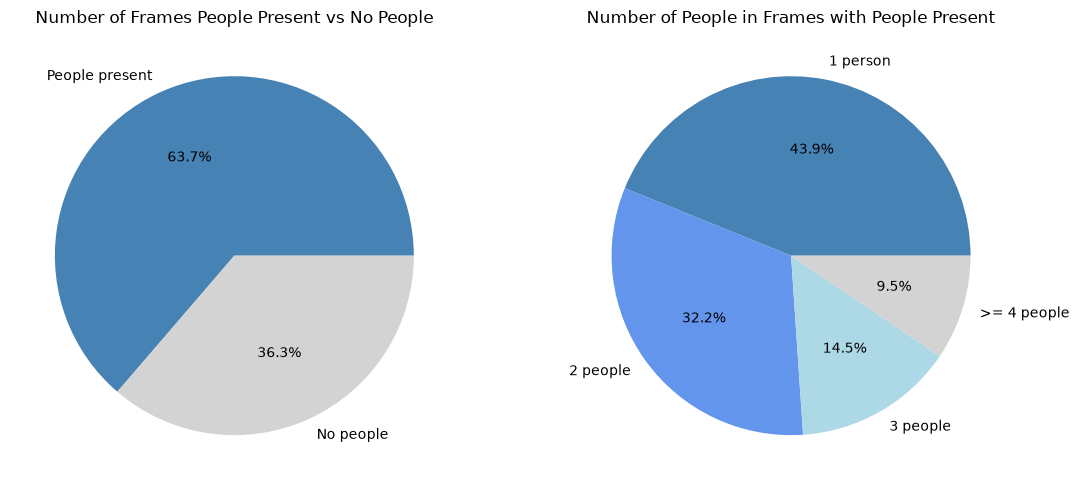

In [8]:
people_present = df[df['obj_id'].notna()]['frame'].nunique()
no_people = df[df['obj_id'].isna()]['frame'].nunique()

people_per_frame = df[df['obj_id'].notna()].groupby(['sequence', 'frame'])['obj_id'].count().reset_index()
counts = people_per_frame['obj_id'].value_counts().sort_index()
count_1 = counts.get(1,0)
count_2 = counts.get(2,0)
count_3 = counts.get(3,0)
count_geq_4 = counts[counts.index >= 4].sum()

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))

ax1.pie([people_present, no_people],
        labels=['People present', 'No people'],
        autopct='%1.1f%%',
        colors = ['steelblue', 'lightgray']
)

ax1.set_title('Number of Frames People Present vs No People')

ax2.pie([count_1, count_2, count_3, count_geq_4],
        labels= ['1 person', '2 people', '3 people', '>= 4 people'],
        autopct='%1.1f%%',
        colors = ['steelblue', 'cornflowerblue', 'lightblue','lightgray']
)

ax2.set_title('Number of People in Frames with People Present')

plt.tight_layout()
plt.show()

For answering our statistical questions we are particularly interested in the activity context of a person. Let us check which different values for the "context" property exist and how often they occur. A bar chart displays this information clearly.

In [9]:
df['context'].value_counts()

context
walking         12516
shop exit       12332
browsing        11662
shop enter       7268
windowshop       2426
shop reenter     1729
immobile         1681
Name: count, dtype: int64

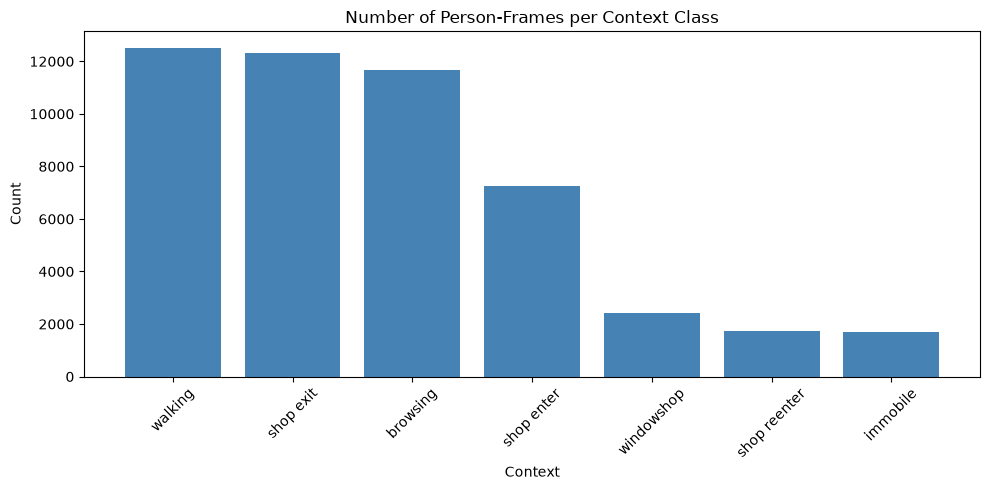

In [10]:
context_counts = df[df['context'].notna()]['context'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar (context_counts.index, context_counts.values, color = 'steelblue')
ax.set_title('Number of Person-Frames per Context Class')
ax.set_xlabel('Context')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Features

In this section we will focus on how to extract not only the information on one person in one frame, but on the whole person's track over multiple frames. Particular interest is the person's mean speed (pixels/frame). The speed between two consecutive frames is computed as $$\sqrt{\Delta x^2 + \Delta y^2}$$ where $$(\Delta x, \Delta y)$$ is the distance between the bounding box center positions. From this the mean and maximum speed and the total distance traveled are derived. Furthermore, we determine the dominant activity label per track. 

In [12]:
def compute_features(track):
    track = track.sort_values('frame')
    dx = track['xc'].diff()
    dy = track['yc'].diff()
    speed = np.sqrt(dx**2 + dy**2)

    area = track['w'] * track['h']
    aspect_ratio = track['h'] / track['w']

    return pd.Series({
        'n_frames':    len(track),
        'mean_speed':  speed.mean(),
        'max_speed':   speed.max(),
        'var_x':       track['xc'].var(),
        'var_y':       track['yc'].var(),
        'mean_w':      track['w'].mean(),
        'mean_h':      track['h'].mean(),
        'mean_area':   area.mean(),
        'std_area':    area.std(),
        'mean_aspect': aspect_ratio.mean(),
        'context':     track['context'].mode()[0]
    })

tracks_df = (df.groupby(['sequence', 'obj_id'], group_keys=False)
               .apply(compute_features, include_groups=False)
               .reset_index())
print(f"{len(tracks_df)} tracks found")
tracks_df.head()

133 tracks found


,sequence,obj_id,n_frames,mean_speed,max_speed,var_x,var_y,mean_w,mean_h,mean_area,std_area,mean_aspect,context
0,EnterExitCrossingPaths1front,0.0,24,1.303291,6.082763,47.853261,3.884058,17.583333,46.333333,870.041667,452.884809,3.457905,walking
1,EnterExitCrossingPaths1front,1.0,27,1.218079,5.000000,19.230769,23.230769,17.074074,44.444444,817.333333,414.473252,2.611950,walking
2,EnterExitCrossingPaths1front,2.0,281,1.369709,15.132746,4054.490849,613.555465,19.245552,49.156584,1048.142349,649.600329,3.041926,shop exit
3,EnterExitCrossingPaths1front,3.0,203,1.163380,21.000000,2123.826513,311.832268,19.083744,48.581281,962.123153,406.278205,2.640899,shop enter
4,EnterExitCrossingPaths2front,0.0,470,0.819623,12.649111,4164.602114,558.371565,17.980851,50.678723,977.036170,536.482563,2.963995,shop exit


Let us check what the dominant activity labels are and how often they occur.

In [13]:
tracks_df['context'].value_counts()

context
walking         66
shop exit       27
shop enter      16
browsing        14
windowshop       4
shop reenter     3
immobile         3
Name: count, dtype: int64

To get a first impression on the mean speed for each activity we calculate the mean speed for all tracks with the same dominant activity.

In [14]:
tracks_df.groupby('context')['mean_speed'].mean().sort_values(ascending=False).round(2).to_frame(name = 'mean speed')

,mean speed
context,
walking,1.80
shop enter,0.99
windowshop,0.86
shop exit,0.84
shop reenter,0.76
browsing,0.57
immobile,0.57


To make it even more informative we plot the mean speed per activity with a boxplot.

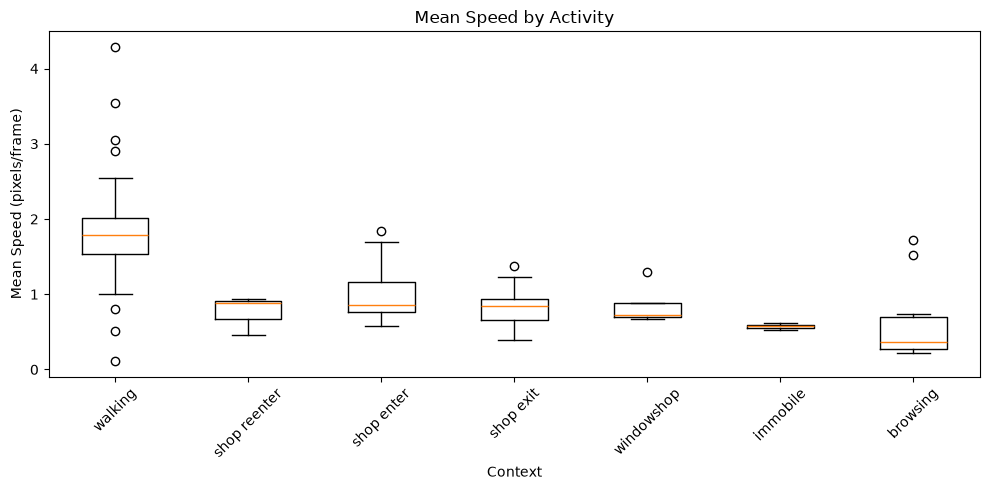

In [16]:
order = tracks_df.groupby('context')['mean_speed'].median().sort_values(ascending= False).index

fig,ax = plt.subplots(figsize = (10,5))
data_plot = [tracks_df[tracks_df['context'] == c]['mean_speed'].values for c in order]
ax.boxplot(data_plot, tick_labels=order)
ax.set_title('Mean Speed by Activity')
ax.set_xlabel('Context')
ax.set_ylabel('Mean Speed (pixels/frame)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Statistical Tests
Next we want to answer the question *Are Walkers faster than Browsers?* 

To do so we implent a two-sample t-test comparing the mean speed of the walking group against the browsing one. 

**Null Hypothesis:** Walkers and Browsers move at the same speed.

In [17]:
from scipy import stats

In [18]:
walkers = tracks_df[tracks_df['context'] == 'walking']['mean_speed']
browsers = tracks_df[tracks_df['context'] == 'browsing']['mean_speed']
t_stat, p_value = stats.ttest_ind(walkers,browsers)
print(f"Walkers: n = {len(walkers)}, mean={walkers.mean():.2f}")
print(f"Browsers: n={len(browsers)}, mean={browsers.mean():.2f}")
print(f"t-statistic:{t_stat:.3f}")
print(f"p-value:{p_value:.8f}")

Walkers: n = 66, mean=1.80
Browsers: n=14, mean=0.57
t-statistic:6.931
p-value:0.00000000


A t-statistic of 6.9 is very large and confirms that the two groups are well sparated. Furthermore, the p-value is way smaller than 0.05. Therefore, we reject the null hypothesis and conclude, that walkers are signigicantly faster than browsers.

Next we want to investigate if people entering and exiting the shop behave in the same way. We again run a t-test.

**Null Hypothesis:** People entering and exiting the shop move at the same speed.

In [19]:
entering = tracks_df[tracks_df['context'] == 'shop enter']['mean_speed']
exiting = tracks_df[tracks_df['context'] == 'shop exit']['mean_speed']
t_stat, p_value = stats.ttest_ind(entering,exiting)
print(f"Entering: n = {len(entering)}, mean={entering.mean():.2f}")
print(f"Exiting: n={len(exiting)}, mean={exiting.mean():.2f}")
print(f"t-statistic:{t_stat:.3f}")
print(f"p-value:{p_value:.8f}")

Entering: n = 16, mean=0.99
Exiting: n=27, mean=0.84
t-statistic:1.674
p-value:0.10180951


The result confirms our null hypothesis. With a p-value signigicantly larger than 0.05 we will not reject the null hypothesis and we conclude that a a differentiation between entering and exiting the shop is not possible based on the mean speed. 

# Conclusion and real-word Application
The Data provided by the CAVIAR project offers a wide range of opportunities to use the skills learned in the python course. 

Using the mean speed to distinguish between different behavois of people is interesting but only partly practical.
While walkers are signigcantly faster than browsers, no signigicant speed difference was found between people entering and exiting the shop, suggesting that mean speed is not sufficient to distinguish these two behaviors. This is also due to the fact that calculating the mean speed the way we did mainly makes sense for people moving from side to side. Speed calculation of people walking in the depth of the image can't be determined in the same way, due to their bounding box centers only moving very little. This leads to an underestimation of their true speed.

Nevertheless, this analysis provides an initial insight into the diverse applications of the dataset.

One could asked themself if working with bounding box coordinates practically used in real life. In practice, hand-labeled ground truth is not available and a very time-consuming task. However, modern object detection models such as YOLOv8 are used for automatically generating bounding box coordinates for every person visible in a frame. These models can be used in near real-time. Working with bounding box coordinates is therfore a practical and widely used approach for extracting information from video data. Applicaations are e.g. crowd monitoring, retail analytics and surveillance.

In [20]:
df[(df['sequence'] == 'TwoLeaveShop1front') & (df['frame'] == 6)]

,sequence,frame,obj_id,xc,yc,h,w,appearance,orientation,movement,role,context,situation
55077,TwoLeaveShop1front,6,0.0,296.0,134.0,55.0,32.0,visible,90,walking,walker,walking,moving



image 1/1 c:\Users\nelly\data_project_Nelly_Harsch\sample_frames\TwoLeaveShop1front0006.jpg: 480x640 2 persons, 1 bench, 224.7ms
Speed: 16.3ms preprocess, 224.7ms inference, 18.4ms postprocess per image at shape (1, 3, 480, 640)


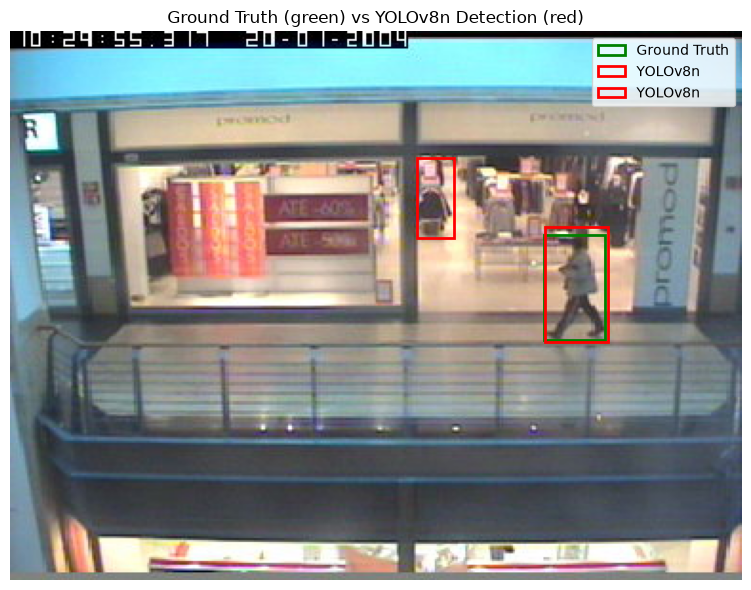

In [23]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

model = YOLO('yolov8n.pt')
img_path = 'sample_frames/TwoLeaveShop1front0006.jpg'
image = Image.open(img_path)
results = model(img_path)

gt = df[(df['sequence'] == 'TwoLeaveShop1front') & (df['frame'] == 6)].iloc[0]
gt_x1 = gt['xc'] - gt['w'] / 2
gt_y1 = gt['yc'] - gt['h'] / 2

fig, ax = plt.subplots(1, figsize = (10,6))
ax.imshow(np.array(image))
rect_gt = patches.Rectangle((gt_x1, gt_y1), gt['w'], gt['h'],
                            linewidth=2, edgecolor='green', facecolor = 'none',
                            label = 'Ground Truth')
ax.add_patch(rect_gt)

for box in results[0].boxes:
    if int(box.cls) == 0:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        rect_yolo = patches.Rectangle(
            (x1, y1), x2 -x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor = 'none',
            label = 'YOLOv8n'
        )
        ax.add_patch(rect_yolo)
ax.legend()
ax.set_title('Ground Truth (green) vs YOLOv8n Detection (red)')
ax.axis('off')
plt.tight_layout()
plt.show() 